## 7.5 LSTM
RNN은 기울기 소멸 문제가 있습니다. 이를 해결하기 위해 LSTM이나 GRU 같은 확장된 RNN 방식들을 사용하고 있습니다.

### 7.5.1 LSTM 구조
LSTM 구조는 순전파와 역전파 과정으로 살펴보겠습니다.

**LSTM 순전파**
LSTM은 기울기 소멸 문제를 해결하기 위해 망각 게이트 입력 게이트 출력 게이트라는 새로운 요소를 은닉층의 각 뉴런에 추가했습니다.

그럼 LSTM에서 사용되는 각 게이트를 자세히 알아보겠습니다.

망각게이트

망각 게이트는 과거 정보를 어느 정도 기 억할지 결정합니다. 과거 정보와 현재 데이터를 입력받아 시그모이드를 취한 후 그 값을 과거 정보에 곱해 줍니다. 따라서 시그모이드의 출력이 0이면 과거 정보는 버리고 1이면 과거 정보는 온전히 보존합니다.

0과 1 사이의 출력 값을 가지는 ht-1과 xt를 입력 값으로 받습니다. 이때 Xf는 새로운 입력 값이고 ht-1은 이전 은닉층에서 입력되는 값입니다. 즉, ht-1과 xt를 이용하여 이전 상태 정보를 현재 메모 리에 반영할지 결정하는 역할을 합니다.

- 계산한 값이 1이면 바로 직전의 정보를 메모리에 유지
- 계산한 값이 0이면 초기화

망각 게이트에 대한 수식은 다음과 같습니다.

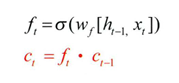

그림으로는 다음과 같이 표현할 수 있습니다.

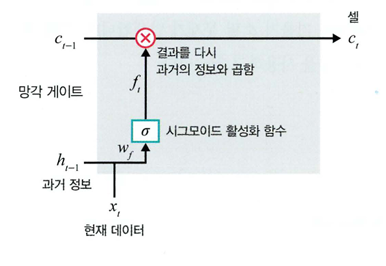

입력게이트

입력 게이트는 현재 정보를 기억하기 위해 만들어졌습니다. 과거 정보와 현재 데이터를 입력받아 시그모이드와 하이퍼볼릭 탄젠트 함수를 기반으로 현재 정보에 대한 보존량을 결정합니다.

즉, 현재 메모리에 새로운 정보를 반영할지 결정하는 역할을 합니다.

- 계산한 값이 1이면 입력 xt가 들어올 수 있도록 허용
- 계산할 값이 0이면 차단

이것을 수식으로 정리하면 다음과 같습니다.

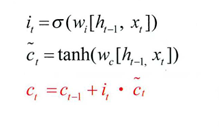

그림으로는 다음과 같이 표현할 수 있습니다.

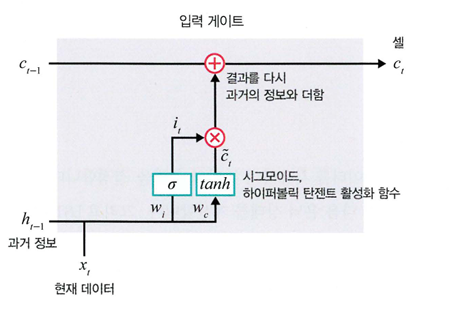

셀

각 단계에 대한 은닉 노드를 메모리 셀이라고 합니다. '총합(sum)'을 사용하여 셀 값을 반영하며, 이것으로 기울기 소멸 문제가 해결됩니다.

셀을 업데이트하는 방법은 다음과 같습니다.

망각 게이트와 입력 게이트의 이전 단계 셀 정보를 계산하여 현재 단계의 셀 상태를 업데이트합니다. 다음은 셀에 대한 수식입니다.

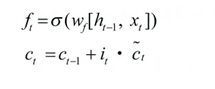

그림으로는 다음과 같이 표현할 수 있습니다.

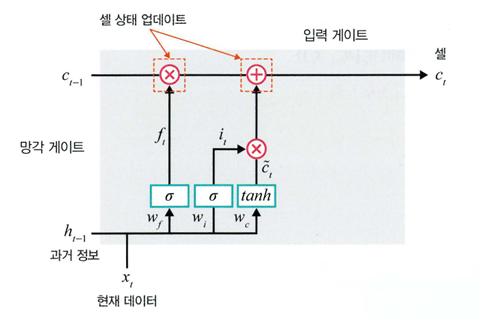

출력게이트

출력 게이트는 과거 정보와 현재 데이터를 시용하여 뉴런의 출력을 결정합니다. 이전 은닉 상태와 t번째 입력을 고려해서 다음 은닉 상태를 계산합니다. 그리고 LSTM에서는 이 은닉 상태가 그 시점에서의 출력이 됩니다.

출력 게이트는 갱신된 메모리의 출력 값을 제어하는 역할을 합니다.

- 계산한 값이 1이면 의미 있는 결과로 최종출력
- 계산한 값이 0이면 해당 연산 출력을 하지 않음

이것을 수식으로 정리하면 다음과 같습니다.

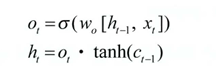

그림으로는 다음과 같이 표현할 수 있습니다.

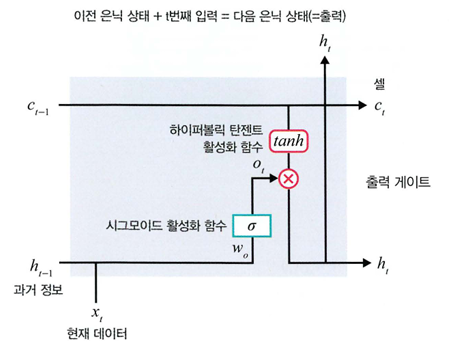

다음 그림은 망각 게이트, 입력 게이트, 출력 게이트를 모두 표현한 것입니다.

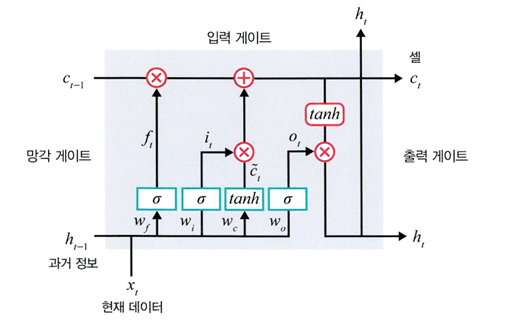

**LSTM 역전파**

LSTM은 셀을 통해서 역전파를 수행하기 때문에 '중단 없는 기울기'라고도 합니다.

즉, 다음 그림과 같이 최종 오자는 모든 노드에 전파되는데, 이때 셀을 통해서 중단 없이 전파됩니다.

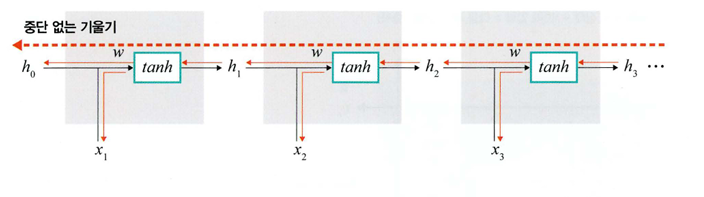

다음은 역전차를 수행하기 위한 공식입니다.

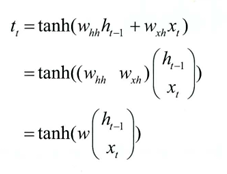

이때 주의해야 할 것은 셀 단위로 오차가 전파된다고 해서 입력 방향으로 오차가 전파되지 않는 것은 아닙니다. 디음 그림과 같이 셀 내부적으로는 오차가 입력으로 전파된다는 것도 잊지 말이야 합니다.

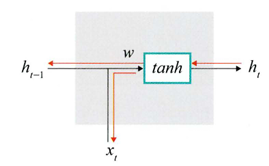

이제 LSTM을 파이토치로 구현해 보겠습니다. LSTM은 RNN과 네트워크 측면에서 어떤 차이가 있는지 비교하면서 학습하면 좋습니다.

### 7.5.2 LSTM 셀 구현
지금까지 RNN을 살펴보았다면 이제 LSTM 셀과 LSTM 계층을 살펴보겠습니다. 이번 예제에서 사용할 데이터셋은 MNIST입니다.

먼저 필요한 라이브러리를 호출합니다.

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dataset
from torch.autograd import Variable
from torch.nn import Parameter # 파라미터 목록을 갖고 있는 라이브러리(패키지)
from torch import Tensor
import torch.nn.functional as F
from torch.utils.data import DataLoader
import math # 수학과 관련되어 다양한 함수들과 상수들이 정의되어 있는 라이브러리
device = torch.device('cuda:8' if torch.cuda.is_available() else 'cpu' )
cuda = True if torch.cuda.is_available() else False # GPU 사용에 필요
Tensor = torch.cuda.FloatTensor if cuda else torch.FloatTensor # GPU 사용에 필요
torch.manual_seed(125)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(125)

데이터에 대한 전처리를 합니다. 평균과 표준편차에 맞게 데이터를 정규화하기 위한 코드입니다.

In [ ]:
import torchvision.transforms as transforms
mnist_transform = transforms.Compose([
  transforms.ToTensor(),
  transforms.Normalize((0.5,), (1.0,)) #평균을 0.5, 표준편차를 1.0으로 데이터 정규화 (데이터 분포를 조정)
])

torchvision.datasets에서 제공하는 데이터셋 중 MNIST 데이터셋을 내려받습니다.

In [ ]:
from torchvision.datasets import MNIST
download_root = './ ESAA' # MNIST를 내려받을 경로
train_dataset = MNIST(download_root, transform=mnist_transform, train=True, download=True) # 1
valid_dataset = MNIST( download_root, transform=mnist_transform, train=False, download=True)
test_dataset = MNIST( download_root, transform=mnist_transform, train=False, download=True)

1 MNIST 데이터셋을 내려받기 위해 필요한 파라미터는 다음과 같습니다.

a. 첫 번째 파라미터: MNIST를 내려받을 위치 지정
b.transform: 앞에서 정의했던 데이터 전처리 적용
c. train: True로 설정할 경우 훈련용 데이터셋을 가져오지만 False로 설정할 경우 테스트용 데이터셋을 가져옵니다.
d. download: True로 설정될 경우 내려받으려는 위치에 MNIST 파일이 없으면 내려받지만 파일이 있다면 내려받지 않습니다.

데이터로더를 이용하여 내려받은 MNIST 파일을 메모리로 불러옵니다. 단， train_loader, valid_loader, test_loader가 호출될 때 메모리로 불러온다는 점에 주의하세요.

In [ ]:
batch_size = 64
train_loader = DataLoader(dataset=train_dataset,
                          batch_size=batch_size,
                          shuffle=True)
valid_loader = DataLoader(dataset=test_dataset,
                          batch_size=batch_size,
                          shuffle=True)
test_loader = DataLoader(dataset=test_dataset,
                         batch_size=batch_size,
                         shuffle=True)

배치 크기 및 에포크 등 변수에 대한 값을 지정합니다.

In [ ]:
batch_size=100
n_iters=6000
num_epochs=n_iters/(len(train_dataset)/batch_size)
num_epochs=int(num_epochs)

LSTM 셀에 대한 네트워크를 구축합니다. 모델의 전반적인 네트워크가 아닌 LSTM 셀에 집중한 네트워크입니다.

In [ ]:
class LSTMCell(nn.Module ):
  def __init__ (self, input_size, hidden_size, bias=True):
    super(LSTMCell, self).__init__()
    self.input_size = input_size
    self.hidden_size = hidden_size
    self.bias = bias
    self.x2h = nn.Linear(input_size, 4 * hidden_size, bias=bias) # 1
    self.h2h = nn.Linear(hidden_size, 4 * hidden_size, bias=bias) # 1'
    self.reset_parameters()

  def reset_parameters(self): # 모델의 파라미터 초기화
    std = 1.0 / math.sqrt(self.hidden_size)
    for w in self.parameters():
      w.data.uniform_(-std, std) # 2

  def forward(self, x, hidden):
    hx, cx = hidden
    x = x.view(-1, x.size(1))

    gates = self.x2h(x) + self.h2h(hx ) # 1''
    gates = gates.squeeze () # 3
    ingate, forgetgate, cellgate, outgate = gates.chunk(4, 1) # 1'''

    ingate = F.sigmoid(ingate) # 입력 게이트에 시그모이드 활성화 함수 적용
    forgetgate = F.sigmoid(forgetgate) # 망각 게이트에 시그모01드 활성화 함수 적용
    cellgate = F.tanh(cellgate) # 셀 게이트에 탄젠트 활성화 함수 적용
    outgate = F.sigmoid(outgate) # 출력 게이트에 시그모이드 활성화 함수 적용

    cy = torch.mul(cx, forgetgate) + torch.mul(ingate, cellgate) # 4
    hy = torch.mul(outgate, F.tanh(cy )) # 4'
    return (hy, cy)

1, 1'에서 4 * hidden_size가 사용되고 있는 이유에 대해 생각해 볼 필요가 있습니다. 왜 은닉층의 뉴런/유닛에 4를 곱하는지 알기 위해 다음 그림을 이해해야 합니다.

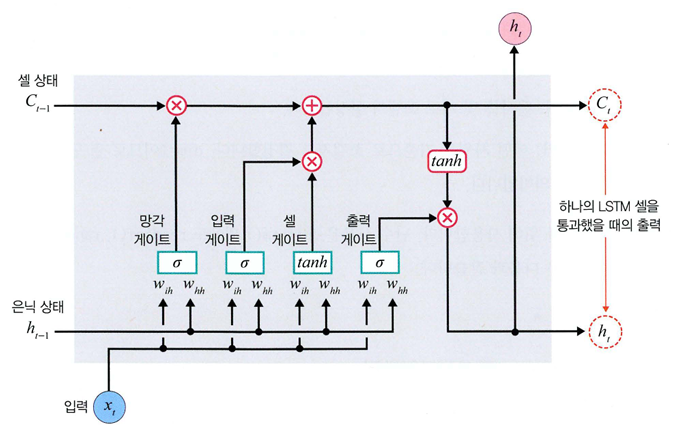


위 그림과 같이 LSTM에서 중요한 것은 게이트입니다. 게이트는 망각, 입력, 셀, 출력으로 수겅되며 이 모든 게이트는 1''처럼 구할 수 있습니다. 1''를 풀어서 작성하면 다음과 같습니다.

a. 입력층으로 입력되는 훈련 데이터셋의 특성 수(칼럼 개수)
b. 입력층과 은닉층 사이의 가중치
c. 입력층과 은닉층 사이의 바이어스
d. 은닉층의 뉴런/유닛 개수(은닉층의 특성 수)
e. 은닉층과 은닉층 사이의 기중치
f. 은닉층과 은닉층 사이의 바이어스

이렇게 계산된 게이트는 1'''처럼 gates.chunk(4, 1)에 의해 네 개로 쪼개져서 각각 망각, 입력, 셀, 출력 게이트를 의미하는 변수에 저장됩니다. 즉, gates가 네 개로 쪼개지는 상황이기 때문에 4가 곱해졌던 것입니다. 일반적으로 바이어스도 4를 곱해 주지만 예제에서는 은닉층의 뉴런/유닛 개수만 4를 곱해 주었습니다.

또한, 여기에서 사용되는 torch.chunk() 사용 방법은 다음과 같습니다.

torch.chunk는 텐서를 쪼갤 때 사용하는 함수이며 파라미터는 다음과 같습니다.

a. 첫 번째 파라미터: 텐서를 몇 개로 쪼갤지 설정합니다.
b. 두 번째 파라미터: 어떤 차원을 기분으로 쪼갤지를 결정합니다. dim=1이므로 열 단위로 텐서를 분할하겠다는 의미입니다.

2 uniform은 난수를 위해 사용합니다. 난수 사용은 uniform() 외에도 randint(), random() 등이 있는데, 사용 방법은 다음과 같습니다.

In [ ]:
# from random import *

# ri = randint(1, 10) # 1부터 10 사이의 임의의 정수
# print(ri)

# rd = random() # 0부터 1 사이의 임의의 실수(float)
# print(rd)

# ui = uniform(1, 10) # 1부터 10 사이의 임의의 실수(float)
# print(ui)

# rr = randrange(1, 18, 2) # 1부터 10 사이를 2씩 건너띈 임의의 정수
# print(rr)

3 torch.squeeze()는 텐서의 차원을 줄이고자 할 때 사용합니다. 사용 방법은 다음과 같습니다.

In [ ]:
# import torch
# X = torch.FloatTensor([[1], [2]]) # (2 x1) 크기의 2차원 텐서 생성
# print(x)
# print(x.shape)
# print('--squeeze 적용--')
# print(x.squeeze()) # squeeze()가 적용되어 1차원으로 축소
# print(x.squeeze().shape)

squeeze()를 적용한 결과 (2 x 1) 텐서가 (2,) 크기를 갖는 1차원 벡터로 변경되었습니다.

4, 4' 하나의 LSTM 셀을 통과하면 셀 상태와 은닉 상태가 출력으로 주어집니다. 이때 셀 상태는 입력, 망각, 셀 게이트에 의해 계산되며 은닉 상태는 출력 게이트에 의해 계산됩니다. 여기에서 사용되는 torch.mul()은 텐서에 곱셈을 할때 시용합니다. 사용 방법은 다음과 같습니다.

In [ ]:
# import torch
# x = torch.FloatTensor([[1], [2]]) # 임의의 텐서 생성
# print(x)
# print('--mu1 적용__')
# torch.mul(x, 3) # x라는 텐서의 원소에 3을 곱합니다.

앞에서 게이트 위주의 셀에 대해 살펴보았다면 이번에는 전반적인 네트워크를 구성해 보겠습니다.

In [ ]:
class LSTMModel(nn.Module):
  def __init__(self, input_dim, hidden_dim, layer_dim, output_dim, bias=True):
    super(LSTMModel, self).__init__()
    self.hidden_dim = hidden_dim # 은닉층의 뉴런/유닛 개수

    self.layer_dim = layer_dim
    self.lstm = LSTMCell(input_dim, hidden_dim) # 1
    self.fc = nn.Linear(hidden_dim, output_dim)

  def forward(self, x):
    if torch.cuda.is_available(): # GPU 사용 유무 확인
      h0 = Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).cuda()) # (은닉층의 계층 개수, 배치 크기, 은닉층의 뉴런 개수) 형태를 갖는 은닉 상태를 0으로 초기화
    else:
      h0 = Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim))

    if torch.cuda.is_available(): # GPU 사용 유무 확인
      c0 = Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).cuda()) # (은닉층의 계층 개수, 배치 크기, 은닉층의 뉴런 개수) 형태를 갖는 셀 상태를 0으로 초기화
    else:
      c0 = Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim))

    outs = []
    cn = c0[0,:,:] # (은닉층의 계층 개수, 배치 크기, 은닉층의 뉴런 개수) 형태를 갖는 셀 상태를 0으로 초기화
    hn = h0[0,:,:] # (은닉층의 계층 개수, 배치 크기, 은닉층의 뉴런 개수) 크기를 갖는 은닉 상태에 대한 텐서

    for seq in range(x.size(1)): # LSTM 셀 계층을 반복하여 쌓아 올립니다.
      hn, cn = self.lstm(x[:,seq,:], (hn, cn)) # 은닉 상태(hn)와 셀 상태를 LSTMCell에 적용한 결과를 또다시 hn, cn에 저장
      outs.append(hn)

    out = outs[-1].squeeze()
    out = self.fc(out)
    return out


CD LSTM 셀은 앞에서 정의한 함수를 불러오는 부분으로 파라미터는 다음과 같습니다.

a. input_dim: 입력에 대한 특성(feature) 수(칼럼 개수)
b. hidden_dim: 은닉층의 뉴런 개수
c. layer_dim: 은닉층의 계층 개수

옵티마이저와 손실 함수를 지정합니다.

In [ ]:
input_dim = 28
hidden_dim = 128
layer_dim = 1
output_dim = 10

model = LSTMModel(input_dim, hidden_dim, layer_dim, output_dim)
if torch.cuda.is_available(): # GPU 사용 유무 확인
  model.cuda()
criterion = nn.CrossEntropyLoss()
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

훈련 데이터셋을 이용하여 모델을 학습시키고 검증 데이터셋을 이용하여 모텔 성능을 확인해 봅니다.

In [ ]:
seq_dim = 28
loss_list = []
iter = 0
for epoch in range(num_epochs):
  for i, (images, labels) in enumerate(train_loader): # 훈련 데이터셋을 이용한 모델 학습
    if torch.cuda.is_available(): # GPU 사용 유무 확인
      images = Variable(images.view(-1, seq_dim, input_dim).cuda()) # 1
      labels = Variable(labels.cuda())
    else: # GPU를 사용하지 않기 떄문에 else 구문이 실행
      images = Variable(images.view(-1, seq_dim, input_dim))
      labels = Variable(labels)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels) # 손실 함수를 이용하여 오차 계산

    if torch.cuda.is_available():
      loss.cuda()

    loss.backward()
    optimizer.step() # 파라미터 업데이트
    loss_list.append(loss.item())
    iter += 1

    if iter % 500 == 0: # 정확도(accuracy) 계산
      correct = 0
      total = 0
      for images, labels in valid_loader: # 검증 데이터셋을 이용한 모델 성능 검증

        if torch.cuda.is_available():
          images = Variable(images.view(-1, seq_dim, input_dim).cuda())
        else:
          images = Variable(images.view(-1, seq_dim, input_dim))

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1) # 모델을 통과한 결과의 최댓값으로부터 예측 결과 가져오기

        total += labels.size(0) # 총 레이블 수
        if torch.cuda.is_available():
          correct += (predicted.cpu() == labels.cpu()).sum()
        else:
          correct += (predicted == labels).sum()

      accuracy = 100 * correct / total
      print('Iteration: {}. Loss: {}. Accuracy: {}'.format(iter, loss.item(), accuracy))

Iteration: 500. Loss: 2.237457513809204. Accuracy: 21.420000076293945
Iteration: 1000. Loss: 0.8865489363670349. Accuracy: 75.66000366210938
Iteration: 1500. Loss: 0.36925092339515686. Accuracy: 89.68000030517578
Iteration: 2000. Loss: 0.22741778194904327. Accuracy: 93.22000122070312
Iteration: 2500. Loss: 0.04691021144390106. Accuracy: 95.62999725341797
Iteration: 3000. Loss: 0.05541188269853592. Accuracy: 95.95999908447266
Iteration: 3500. Loss: 0.08951079845428467. Accuracy: 96.51000213623047
Iteration: 4000. Loss: 0.02204427309334278. Accuracy: 96.95999908447266
Iteration: 4500. Loss: 0.07599193602800369. Accuracy: 96.76000213623047
Iteration: 5000. Loss: 0.05491260439157486. Accuracy: 97.11000061035156
Iteration: 5500. Loss: 0.16436734795570374. Accuracy: 96.5199966430664
Iteration: 6000. Loss: 0.01572381891310215. Accuracy: 97.20999908447266
Iteration: 6500. Loss: 0.01401564758270979. Accuracy: 97.88999938964844
Iteration: 7000. Loss: 0.01943875104188919. Accuracy: 97.91999816894

1 현재 버전에서는 모든 텐서가 자동으로 Variable의 성질을 갖기 때문에 torch.autograd.Variable을 사용할 필요가 없지만 학습/연습 및 이전 버전에서 구현된 파이토치 코드를 이해하기 위해 사용합니다.

정확도가 97%로 상당히 높은 것을 확인할 수 있습니다.

이제 테스트 데이터셋을 이용하여 모델 예측 성능을 살펴보겠습니다.

In [ ]:
def evaluate(model, val_iter):
  corrects, total, total_loss = 0, 0, 0
  model.eval()
  for images, labels in val_iter:
    if torch.cuda.is_available(): # GPU 사용 유무 확인
      images = Variable(images.view(-1, seq_dim, input_dim).cuda())
      labels = labels.cuda()
    else:
      images = Variable(images.view(-1, seq_dim, input_dim)).to(device)
      labels = labels.to(device)

    logit = model(images).to(device)
    loss = F.cross_entropy(logit, labels, reduction="sum") # reduction = 'sum'을 지정했기 때문에 모든 오차를 더합니다.
    _, predicted = torch.max(logit.data, 1) # logit.data 텐서에서 최댓값의 인덱스를 반환
    total += labels.size(0)
    total_loss += loss.item()
    corrects += (predicted == labels).sum()

  avg_loss = total_loss / len(val_iter.dataset)
  avg_accuracy = corrects / total
  return avg_loss, avg_accuracy


모댈 학습 및 모댈 예측 관련한 코드는 비슷한 패턴으로 진행됩니다. 따라서 모델의 네트워크 및 네트워크에서 시용되는 파라미터에 집중하여 학습하면 좋습니다.

마지막으로 테스트 데이터셋을 이용한 모델 예측 성능을 확인해 봅니다.

In [ ]:
test_loss, test_acc = evaluate(model, test_loader)
print("Test Loss: %5.2f : Test Accuracy: %5.2f"%(test_loss, test_acc))

Test Loss:  0.07 : Test Accuracy:  0.98


IMDB에서 MNIST로 데이터셋이 바뀌기는 했지만 98%로 성능이 매우 좋습니다.IMDB는 사전에 전처리가 되지 않은 데이터셋이고 MNIST는 사전에 전처리가 된 상태의 데이터셋이기 때문에 정확도 측면에서 차이가 날 수 있습니다. 이와 같이 사전에 전처리가 되지 않은 데이터셋의 경우 정확도를 높이기 위해 은닉층의 개수(혹은 뉴런의 개수) 및 하이퍼파라미터 수정 등이 필요합니다.

### 7.5.3 LSTM 계층 구현
LSTM 계층에 대한 예제 데이터셋은 스타벅스 주가 데이터셋을 시용합니다. 또한, 예제를 통해 확인하고자 하는 것은 모델이 얼마나 주가 예측을 잘 하는지에 대해 알아보는 것입니다.

먼저 필요한 라이브러리를 호출합니다.

In [49]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.autograd import Variable
from tqdm import tqdm_notebook
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

device = torch.device('cud:0' if torch.cuda.is_available() else 'cpu')

이번 예제에서 사용할 데이터셋은 스타벅스 주가입니다.

In [50]:
data = pd.read_csv('SBUX.csv')
print(data .dtypes)

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object


다음은 스타벅스 주가 데이터셋의 각 칼럼과 데이터 타입을 보여 줍니다.

데이터셋에 포함된 'Date' 칼럼을 인텍스로 시용하도록 합니다. 이번 예제에서 사용할 데이터들은 숫자이기 때문에 임베딩이 필요하지 않지만 단어들로 구성된 데이터셋은 임베딩 과정을 거쳐야 합니다. 이때 날짜 칼럼은 임베딩 처리가 어려운 경우가 많은데, 날짜 칼럼을 인텍스로 처리하면 편리합니다.

In [51]:
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True) # 'date' 칼럼을 인덱스로 사용

'Volume' 칼럼은 정수(int)라는 데이터 형식을 갖는데. 이것을 실수(float)로 변경합니다. 여기도 마찬가지로 데이터 형식을 실수로 맞추고 시작하면 추후 데이터를 댄서로 변환할 때 편리합니다.

In [52]:
data['Volume'] = data['Volume'].astype(float) # 데이터 형식을 변경할 때는 astype()을 사용

데이터에 대한 전처리가 완료되었다면 데이터셋을 훈련과 정답(레이블)으로 분리하고 그 결과를 출력합니다.

In [53]:
X = data.iloc[:, :-1] #  마지막 칼럼을 제외한 모든 칼럼을 X로 사용
y = data.iloc[:, 5:6] # 마지막 'Volums'을 레이블로 사용
print(X)
print(y)

                  Open        High         Low       Close   Adj Close
Date                                                                  
2019-12-11   86.260002   86.870003   85.849998   86.589996   84.145752
2019-12-12   88.000000   88.889999   87.540001   88.209999   85.720032
2019-12-13   88.019997   88.790001   87.580002   88.669998   86.167046
2019-12-16   89.139999   89.300003   88.430000   88.779999   86.273941
2019-12-17   88.870003   88.970001   87.470001   88.129997   85.642288
...                ...         ...         ...         ...         ...
2020-12-04  101.349998  102.940002  101.070000  102.279999  101.442787
2020-12-07  102.010002  102.220001  100.690002  101.410004  100.579918
2020-12-08  100.370003  101.570000  100.010002  101.209999  100.381554
2020-12-09  101.940002  102.209999  100.099998  100.400002   99.578186
2020-12-10  103.510002  106.089996  102.750000  105.389999  104.527336

[253 rows x 5 columns]
                Volume
Date                  
2019-12

데이터셋에서 데이터 간의 분포가 다르게 나타나고 있습니다. 분포를 고르게 맞추기 위한 과정이 필요한데 MinMaxScaler()와 StandardScaler()를 사용하여 분산을 조정해 보겠습니다.

In [54]:
ms = MinMaxScaler() # 데이터의 모든 값이 0~1 사이에 존재하도록 분산 조정
ss = StandardScaler() # 데이터가 평균 0, 분산 1이 되도록 분산 조정

X_ss = ss.fit_transform(X)
y_ms = ms.fit_transform(y)

X_train = X_ss[:200, :] # 훈련 데이터셋
X_test = X_ss[200:, :] # 테스트 데이터셋

y_train = y_ms[:200, :]
y_test = y_ms[200:, :]

print("Training Shape", X_train.shape, y_train.shape)
print("Testing Shape", X_test.shape, y_test.shape)

Training Shape (200, 5) (200, 1)
Testing Shape (53, 5) (53, 1)


훈련 데이터셋(X_train)은 200개의 데이터와 다섯 개의 칼럼으로 구성되어 있으며, 테스트 데이터셋(y_test)은 53개의 데이터와 한 개의 칼럼으로 구성되어 있는 것을 확인할 수 있습니다.

모든 데이터셋은 그 자체로 네트워크에 보낼 수 없습니다. 네트워크에서 정의된 형태 및 크기에 따라 데이터셋 크기를 조정한 후 네트워크로 보내야 합니다.

In [55]:
X_train_tensors = Variable(torch.Tensor(X_train)) # Variable로 감싸진 텐서는 .backward()가 호출될 때 자동으로 기울기가 계산
X_test_tensors = Variable(torch.Tensor(X_test))

y_train_tensors = Variable(torch.Tensor(y_train))
y_test_tensors = Variable(torch.Tensor(y_test))

X_train_tensors_f = torch.reshape(X_train_tensors, (X_train_tensors.shape[0], 1, X_train_tensors.shape[1])) # 1
X_test_tensors_f = torch.reshape(X_test_tensors, (X_test_tensors.shape[0], 1, X_test_tensors.shape[1]))

print("Training Shape", X_train_tensors_f.shape, y_train_tensors.shape)
print("Testing Shape", X_test_tensors_f.shape, y_test_tensors.shape)

Training Shape torch.Size([200, 1, 5]) torch.Size([200, 1])
Testing Shape torch.Size([53, 1, 5]) torch.Size([53, 1])


1 torch.reshape은 텐서의 형태를 바꿀 때 사용하며, 훈련 데이터셋(X_ train_ tensors)의 형태(200, 5)를 (200, 1, 5)로 변경하겠다는 의미입나다.

이와 같이 데이터셋의 형태를 변경히는 이유는 LSTM 네트워크의 입력 형태와 맞추기 위함입니다. 이제 LSTM 모델의 네트워크를 구성해 봅니다.

In [56]:
class LSTM(nn.Module):
  def __init__(self, num_classes, input_size, hidden_size, num_layers, seq_length):
    super(LSTM, self).__init__()
    self.num_classes = num_classes # 클래스 개수
    self.num_layers = num_layers # LSTM 계층의 개수
    self.input_size = input_size # 입력 크기로 훈련 데이터셋의 칼럼 개수를 의미
    self.hidden_size = hidden_size # 은닉층의 뉴런 개수
    self.seq_length = seq_length # 시퀀스 길이

    self.lstm = nn.LSTM(input_size = input_size, hidden_size = hidden_size,
                        num_layers = num_layers, batch_first = True) # LSTM 계층
    self.fc_1 = nn.Linear(hidden_size, 128) # 완전연결층
    self.fc = nn.Linear(128, num_classes) # 출력층
    self.relu = nn.ReLU()

  def forward(self, x):
    h_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) # 은닉 상태를 0으로 초기화
    c_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) # 셀 상태를 0으로 초기화
    output, (hn, cn) = self.lstm(x, (h_0, c_0)) # LSTM 계층에 은닉 상태와 셀 상태 적용
    hn = hn.view(-1, self.hidden_size) # 완전연결층 적용을 위해 데이터의 형태 조정(1차원으로 조정)
    out = self.relu(hn)
    out = self.fc_1(out)
    out = self.relu(out)
    out = self.fc(out)
    return out

모델 학습을 위해 필요한 변수 값들을 설정합니다.

In [57]:
num_epochs = 1000 # 1000번의 에포크
learning_rate = 0.0001 # 학습률을 0.0001로 지정

input_size = 5 # 입력 데이터셋의 칼럼 개수
hidden_size = 2 # 은닉층의 뉴런/유닛 개수
num_layers = 1 # LSTM 계층의 개수

num_classes = 1 # 클래스 개수
model = LSTM(num_classes, input_size, hidden_size, num_layers, X_train_tensors_f.shape[1]) # 앞에서 정의한 값들을 이용하여 LSTM 모델 학습

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

이제 모델을 학습시킵니다.

In [58]:
for epoch in range(num_epochs): # 1000번 반복
  outputs = model.forward(X_train_tensors_f) # 전방향(forward) 학습
  optimizer.zero_grad()
  loss = criterion(outputs, y_train_tensors) # 손실 함수를 이용한 오차 계산(모델 학습 결과와 레이블의 차이 계산)
  loss.backward() # 기울기 계산

  optimizer.step() # 오차 업데이트
  if epoch % 100 == 0: # 1000을 100으로 나누어 나머지가 0이면 출력
    print("Epoch: %d, loss: %1.5f" % (epoch, loss.item()))

Epoch: 0, loss: 0.18287
Epoch: 100, loss: 0.05713
Epoch: 200, loss: 0.03855
Epoch: 300, loss: 0.03717
Epoch: 400, loss: 0.03599
Epoch: 500, loss: 0.03326
Epoch: 600, loss: 0.02937
Epoch: 700, loss: 0.02517
Epoch: 800, loss: 0.02214
Epoch: 900, loss: 0.02038


오차 위주로 출력했기 때문에 실제로 얼마나 잘 예측했는지 알기 어렵습니다. 예측 결괴를 시각적으로 표현해 보겠습니다. 먼저 레이블과 예측 결과를 출력하기 위한 전처리(데이터의 분포 및 형태 변경)를 진행합니다.

In [59]:
df_x_ss = ss.transform(data.iloc[:, :-1]) # 데이터 정규화(분포 조정)
df_y_ms = ms.transform(data.iloc[:, -1:]) # 데이터 정규화

df_x_ss = Variable(torch.Tensor(df_x_ss))
df_y_ms = Variable(torch.Tensor(df_y_ms))
df_x_ss = torch.reshape(df_x_ss, (df_x_ss.shape[0], 1, df_x_ss.shape[1]))

전처리가 진행된 데이터를 그래프로 출력합니다.

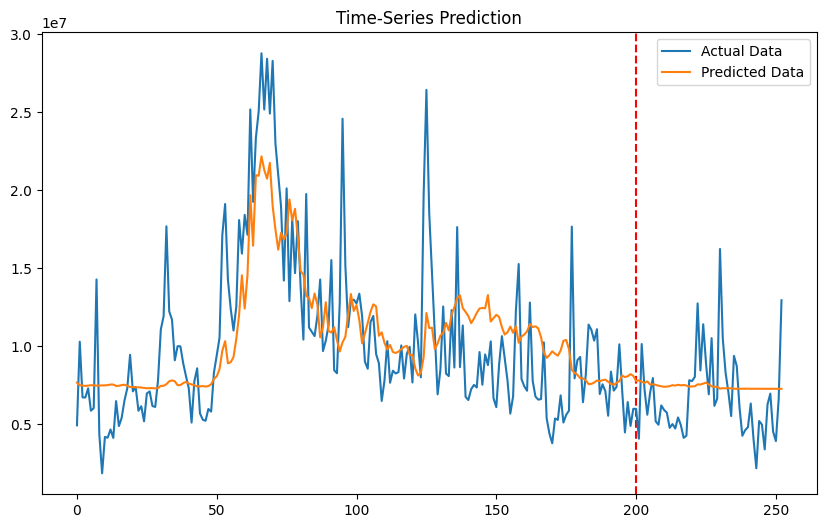

In [60]:
train_predict = model(df_x_ss) # 훈련 데이터셋을 모델에 적용하여 모델 학습
predicted = train_predict.data.numpy() # 모델 학습 결과를 넘파이로 변경
label_y = df_y_ms.data.numpy()

predicted = ms.inverse_transform(predicted) # 모델 학습을 위해 전처리(정규화)했던 것을 해제 (그래프의 본래 값을 출력하기 위한 목적)
label_y = ms.inverse_transform(label_y)
plt.figure(figsize = (10, 6)) # 그래프로 표시
plt.axvline(x=200, c='r', linestyle = '--') # 1

plt.plot(label_y, label = 'Actual Data')
plt.plot(predicted, label = 'Predicted Data')
plt.title('Time-Series Prediction')
plt.legend()
plt.show()

1 axvline()은 그래프의 축을 따라 수직선을 표현할 때 시용하며 파라미터는 다음과 같습니다.

a. 첫 번째 파라미터 : 어떤 지점에 수직선을 표현할지 지정합니다.
b. c: 어떤 색상으로 수직선을 표현할지 지정합니다.
c. linestyle: 어떤 스타일로 수직선을 표현할지 지정합니다. 참고로 수평선은 axhline()을 시용하며 다음 그림과 같이 표현할 때 사용합니다.

파란색은 실제 레이블에 대한 출력 결과이고 주황색은 모벨이 예측한 결과를 보여 줍니다. 예측 결과가 만족스럽지 않습니다. 추후 GRU에 대해서도 통일한 데이터셋을 사용해 볼 텐데 결과를 비교해 보겠습니다. 이와 같이 결과가 만족스럽지 않다면 하이퍼파라미터에 대한 튜닝도 중요하지만 모델을 변경해 보는 것이 좋습니다.